# Phase 0 — Data Exploration

**Mục tiêu:** Khám phá và đánh giá chất lượng hai nguồn dữ liệu nền tảng trước khi bước vào Phase 1 (Ingestion):

1. **Corpus văn bản pháp luật** (`vbpl_sample.jsonl`, nguồn `tmquan/vbpl-vn`) — dữ liệu chính để chunking + index hóa.
2. **Ground truth retrieval** (`retrieval_eval_train.jsonl`, nguồn `YuITC/Vietnamese-Legal-Doc-Retrieval-Data`) — bộ câu hỏi/đáp chuẩn để đánh giá Retrieval Layer ở Phase 2.

**Câu hỏi cốt lõi notebook này cần trả lời:**
- Corpus có sạch, có đại diện đủ tốt cho pipeline chunking ở Phase 1 không?
- Ground truth retrieval có cấu trúc thế nào, dùng cột nào để lấy nhãn đúng — bảo (`relevant_passage_ids`) không tồn tại trong dữ liệu thật?
- **Quan trọng nhất:** hai nguồn dữ liệu này có cùng "không gian ID" hay không? Nếu không, `retrieval_eval_train.jsonl` có dùng trực tiếp để đo Recall@k trên `vbpl_sample` ở Phase 2 được hay không?

**Nội dung notebook:**
- [1. Thiết lập môi trường](#1)
- [2. Khám phá corpus văn bản pháp luật](#2)
- [3. Khám phá dữ liệu ground truth retrieval](#3)
- [4. Kiểm tra tính nhất quán giữa hai nguồn dữ liệu](#4)
- [5. Khám phá adversarial eval](#5)
- [6. Tổng kết & khuyến nghị cho Phase 1](#6)

<a id='1'></a>
## 1. Thiết lập môi trường

In [26]:
import json
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 120)
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

PALETTE = {
    'primary': '#4C72B0',
    'secondary': '#55A868',
    'warn': '#DD8452',
    'danger': '#C44E52',
    'neutral': '#8C8C8C',
}

In [27]:
# --- Cấu hình đường dẫn ---
VBPL_PATH = Path('../data/raw/laws/vbpl_sample.jsonl')
RETRIEVAL_EVAL_PATH = Path('../data/eval/retrieval_eval_train.jsonl')

# Giới hạn số dòng đọc mẫu cho tập ground truth 
RETRIEVAL_SAMPLE_LIMIT = 1000

OUTLIER_PERCENTILE = 0.99
CONTENT_OVERLAP_SNIPPET_LEN = 40  

In [28]:
def load_jsonl(path: Path, limit: int | None = None) -> list[dict]:
    '''Đọc file .jsonl thành list các dict.

    Args:
        path: Đường dẫn tới file .jsonl.
        limit: Nếu được cung cấp, chỉ đọc tối đa `limit` dòng đầu tiên.

    Returns:
        Danh sách các bản ghi đã parse từ JSON Lines.

    Raises:
        FileNotFoundError: Nếu file không tồn tại tại đường dẫn cho trước.
    '''
    if not path.exists():
        raise FileNotFoundError(
            f"Không tìm thấy file: {path.resolve()}\n"
            "Kiểm tra lại đường dẫn hoặc chạy script tải dữ liệu ở Phase 0 trước."
        )

    records = []
    with open(path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if limit is not None and i >= limit:
                break
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as e:
                print(f"[Cảnh báo] Bỏ qua dòng {i} do lỗi parse JSON: {e}")
    return records


def safe_json_loads(x):
    '''Parse một chuỗi JSON lồng bên trong cột (vd: structure_json, extracted_json).

    Trả về dict rỗng nếu giá trị không phải chuỗi JSON hợp lệ, thay vì raise lỗi —
    các cột này thường không đồng nhất 100% giữa các bản ghi nên cần khoan dung.
    '''
    if not isinstance(x, str):
        return {}
    try:
        return json.loads(x)
    except (json.JSONDecodeError, TypeError):
        return {}


def pct(part, whole):
    '''Định dạng phần trăm an toàn khi whole = 0.'''
    return f"{part / whole:.1%}" if whole else "N/A"


### 1.1. Data dictionary tóm tắt

**`vbpl_sample.jsonl`** — mỗi dòng là **một văn bản pháp luật hoàn chỉnh**:
| Cột | Ý nghĩa |
|---|---|
| `item_id`, `doc_name` | ID định danh văn bản trong tập `vbpl-vn` (thường trùng nhau) |
| `title`, `doc_type`, `legal_type`, `legal_area` | Metadata phân loại |
| `issuing_authority`, `issue_date`, `year` | Cơ quan ban hành, ngày/năm |
| `markdown` | **Nội dung văn bản đã chuẩn hóa** — nguồn chính cho chunking Phase 1 |
| `num_sections`, `num_paragraphs`, `num_sentences`, `char_len` | Số liệu cấu trúc do parser tính sẵn |
| `structure_json`, `extracted_json` | JSON lồng — chứa cấu trúc phân cấp điều/khoản và entities đã trích xuất |

**`retrieval_eval_train.jsonl`** — mỗi dòng là **một câu hỏi** kèm passage liên quan:
| Cột | Ý nghĩa |
|---|---|
| `question` | Câu hỏi tự nhiên |
| `context_list` | Danh sách **text** của (các) passage liên quan (không phải ID) |
| `qid` | ID của câu hỏi |
| `cid` | Danh sách **ID** của (các) passage liên quan, khớp theo thứ tự với `context_list` |


<a id='2'></a>
## 2. Khám phá corpus văn bản pháp luật (`vbpl_sample.jsonl`)

In [29]:
vbpl_records = load_jsonl(VBPL_PATH)
df_vbpl = pd.DataFrame(vbpl_records)

print(f"Tổng số văn bản: {len(df_vbpl):,}")
print(f"Số cột: {len(df_vbpl.columns)}")
print(f"Bộ nhớ sử dụng (ước lượng): {df_vbpl.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nCác cột hiện có:\n{list(df_vbpl.columns)}")
df_vbpl.head(3)

Tổng số văn bản: 2,800
Số cột: 30
Bộ nhớ sử dụng (ước lượng): 565.6 MB

Các cột hiện có:
['doc_name', 'item_id', 'scope', 'source', 'source_url', 'api_url', 'title', 'doc_type', 'legal_type', 'legal_area', 'doc_number', 'issue_date', 'year', 'issuing_authority', 'summary', 'markdown', 'num_pages', 'num_sections', 'num_paragraphs', 'num_sentences', 'char_len', 'text_hash', 'parser_model', 'parser_runtime', 'body_source', 'parsed_at', 'confidence', 'structure_json', 'extracted_json', 'file_paths_json']


,doc_name,item_id,scope,source,source_url,api_url,title,doc_type,legal_type,legal_area,...,char_len,text_hash,parser_model,parser_runtime,body_source,parsed_at,confidence,structure_json,extracted_json,file_paths_json
0,1,1,trung_uong,vbpl.vn,https://vbpl.vn/van-ban/chi-tiet/nghi-dinh-so-24-ld-nd-to-chuc-cac-co-quan-lao-dong-dia-phuong-lien-khu-va-tinh--1,https://vbpl-bientap-gateway.moj.gov.vn/api/qtdc/public/doc/1,Tổ chức các cơ quan Lao động địa phương liên khu và tỉnh,nghi_dinh,Nghị định,Chưa phân loại,...,1149,6bba1a9f1ebb47741d63ffa6b2d29313,local/markdownify,local,body_html,2026-05-21T10:37:41+00:00,NaN,"{""schema_version"": ""1.0"", ""doc_id"": ""1"", ""meta"": {""doc_id"": ""1"", ""doc_name"": ""1"", ""doc_type"": null, ""doc_subtype"": n...","{""doc_id"": ""1"", ""text_hash"": ""6bba1a9f1ebb47741d63ffa6b2d29313"", ""char_len"": 1149, ""entities"": [{""tag"": ""DATE"", ""tex...",NaN
1,10,10,trung_uong,vbpl.vn,https://vbpl.vn/van-ban/chi-tiet/thong-tu-so-41-nv-6-tt-dinh-the-le-xep-cong-chuc-vao-thang-luong-chung-theo-nang-lu...,https://vbpl-bientap-gateway.moj.gov.vn/api/qtdc/public/doc/10,Định thể lệ xếp công chức vào thang lương chung theo năng lực,thong_tu,Thông tư,Chưa phân loại,...,9007,7e65525e49a4ec387ad9fe4059a2c9be,local/markdownify,local,body_html,2026-05-21T10:37:41+00:00,NaN,"{""schema_version"": ""1.0"", ""doc_id"": ""10"", ""meta"": {""doc_id"": ""10"", ""doc_name"": ""10"", ""doc_type"": ""quyet_dinh"", ""doc_...","{""doc_id"": ""10"", ""text_hash"": ""7e65525e49a4ec387ad9fe4059a2c9be"", ""char_len"": 9007, ""entities"": [{""tag"": ""DATE"", ""te...",NaN
2,100,100,trung_uong,vbpl.vn,https://vbpl.vn/van-ban/chi-tiet/sac-lenh-so-68-sl-thanh-lap-ban-kinh-te-chinh-phu--100,https://vbpl-bientap-gateway.moj.gov.vn/api/qtdc/public/doc/100,thành lập Ban Kinh tế Chính phủ,sac_lenh,Sắc lệnh,Chưa phân loại,...,1410,d6cc61bd026b0f639659bcdbe9765f29,local/markdownify,local,body_html,2026-05-21T10:37:41+00:00,NaN,"{""schema_version"": ""1.0"", ""doc_id"": ""100"", ""meta"": {""doc_id"": ""100"", ""doc_name"": ""100"", ""doc_type"": null, ""doc_subty...","{""doc_id"": ""100"", ""text_hash"": ""d6cc61bd026b0f639659bcdbe9765f29"", ""char_len"": 1410, ""entities"": [{""tag"": ""ARTICLE"",...",NaN


### 2.1. Kiểm tra chất lượng dữ liệu


In [30]:
missing = df_vbpl.isnull().sum()
missing_pct = (missing / len(df_vbpl) * 100).round(1)
missing_summary = pd.DataFrame({'số dòng thiếu': missing, 'tỷ lệ (%)': missing_pct})
missing_summary = missing_summary[missing_summary['số dòng thiếu'] > 0].sort_values('số dòng thiếu', ascending=False)

print("Các cột có giá trị thiếu (chỉ hiện cột > 0):")
display(missing_summary)

id_col = 'item_id' if 'item_id' in df_vbpl.columns else ('doc_id' if 'doc_id' in df_vbpl.columns else None)
print(f"\n{'—' * 60}")
if id_col:
    n_dup_id = df_vbpl[id_col].duplicated().sum()
    print(f"Số văn bản trùng '{id_col}': {n_dup_id}")

if 'markdown' in df_vbpl.columns:
    n_dup_md = df_vbpl['markdown'].dropna().duplicated().sum()
    print(f"Số văn bản trùng nội dung (markdown, bỏ qua NaN): {n_dup_md}")

if 'text_hash' in df_vbpl.columns:
    n_dup_hash = df_vbpl['text_hash'].dropna().duplicated().sum()
    print(f"Số văn bản trùng text_hash (bỏ qua NaN): {n_dup_hash}")

n_missing_markdown = df_vbpl['markdown'].isnull().sum() if 'markdown' in df_vbpl.columns else 0
print(f"\n Số văn bản KHÔNG có nội dung markdown: "
      f"{n_missing_markdown} / {len(df_vbpl)} ({pct(n_missing_markdown, len(df_vbpl))}) "
      f"— các văn bản này sẽ bị loại khỏi pipeline ingestion.")

Các cột có giá trị thiếu (chỉ hiện cột > 0):


,số dòng thiếu,tỷ lệ (%)
summary,2800,100.0
num_pages,2800,100.0
confidence,2800,100.0
file_paths_json,2800,100.0
markdown,356,12.7
text_hash,356,12.7
doc_number,39,1.4
issue_date,7,0.2
year,7,0.2
issuing_authority,6,0.2



————————————————————————————————————————————————————————————
Số văn bản trùng 'item_id': 0
Số văn bản trùng nội dung (markdown, bỏ qua NaN): 1
Số văn bản trùng text_hash (bỏ qua NaN): 1

 Số văn bản KHÔNG có nội dung markdown: 356 / 2800 (12.7%) — các văn bản này sẽ bị loại khỏi pipeline ingestion.


### 2.2. Phân bố loại văn bản, lĩnh vực pháp lý và cơ quan ban hành

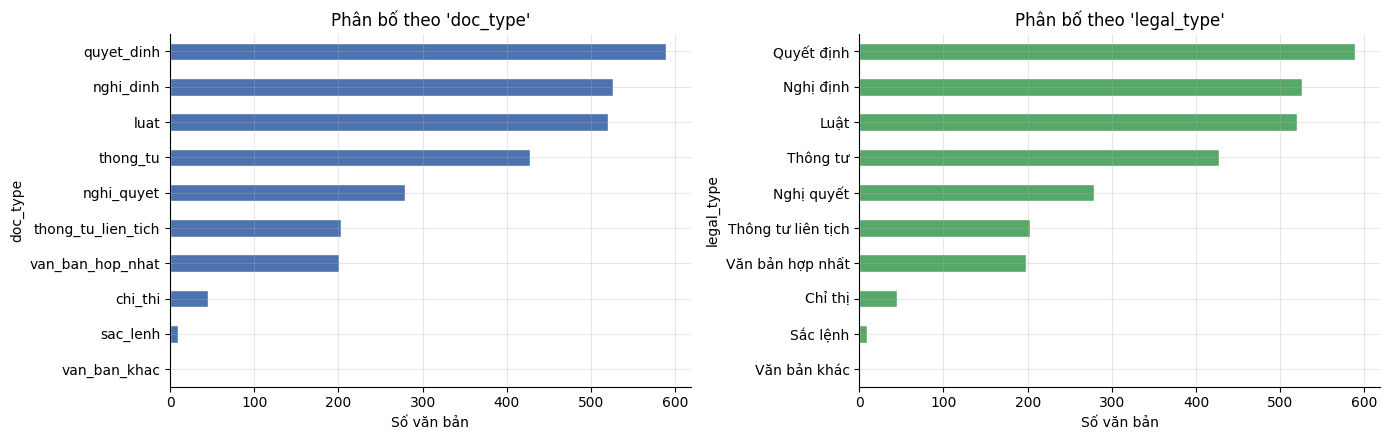

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, col, color in zip(axes, ['doc_type', 'legal_type'], [PALETTE['primary'], PALETTE['secondary']]):
    if col in df_vbpl.columns:
        counts = df_vbpl[col].value_counts()
        counts.plot(kind='barh', ax=ax, color=color, edgecolor='white')
        ax.invert_yaxis()
        ax.set_title(f"Phân bố theo '{col}'")
        ax.set_xlabel('Số văn bản')
    else:
        ax.set_visible(False)
        print(f"[Bỏ qua] Không tìm thấy cột '{col}'.")

plt.tight_layout()
plt.show()

### Nhận xét

Hai biểu đồ `doc_type` và `legal_type` phản ánh cùng một thông tin dưới hai định dạng khác nhau:
`doc_type` là dạng snake_case dùng trong code, `legal_type` là tên tiếng Việt dùng để hiển thị. Phân bố của hai cột hoàn toàn trùng khớp, xác nhận đây là thông tin dư thừa — chỉ cần giữ một cột khi xây dựng metadata cho hệ thống.

Về cơ cấu phân bố:

- **Quyết định** (~580) chiếm tỷ lệ cao nhất, khoảng 46% tổng corpus.
- **Nghị định** (~530) và **Luật** (~520) xấp xỉ nhau, là hai loại văn bản có giá trị pháp lý cao và được người dùng tra cứu nhiều nhất trong thực tế.
- **Thông tư** (~430) chiếm tỷ lệ đáng kể, bổ trợ tầng hướng dẫn thi hành chi tiết.
- **Nghị quyết** (~280): phản ánh các văn bản mang tính định hướng chính sách.
- **Thông tư liên tịch**, **Văn bản hợp nhất** (~200 mỗi loại): chiếm tỷ lệ nhỏ.
- **Chỉ thị**, **Sắc lệnh**, **Văn bản khác**: rất ít, phù hợp với tần suất ban hành thực tế.

### Kết luận

Corpus có cơ cấu tương đối đa dạng và phù hợp với bài toán hỏi đáp pháp luật:

- Các loại văn bản nền tảng (Luật, Nghị định) chiếm tỷ trọng lớn, đảm bảo hệ thống RAG có thể trả lời các câu hỏi về quyền, nghĩa vụ và chế tài pháp lý từ nguồn gốc.
- Thông tư chiếm tỷ lệ đáng kể, hỗ trợ các câu hỏi về thủ tục và quy trình cụ thể.
- Quyết định tuy chiếm nhiều nhất nhưng không áp đảo, và vẫn có giá trị khi trả lời các câu hỏi tình huống liên quan đến chính sách, đối tượng áp dụng và mức xử phạt.
- Chỉ thị và Sắc lệnh xuất hiện rất ít — không ảnh hưởng đến chất lượng hệ thống vì tần suất hỏi về các loại văn bản này trong thực tế cũng rất thấp.


In [32]:
if 'legal_area' in df_vbpl.columns:
    area_counts = df_vbpl['legal_area'].value_counts()
    print("Phân bố theo lĩnh vực pháp lý ('legal_area'):")
    display(area_counts)
    unclassified = area_counts.get('Chưa phân loại', 0)
    if unclassified:
        print(f"\n[Lưu ý] {unclassified} văn bản ({pct(unclassified, len(df_vbpl))}) chưa được gán lĩnh vực pháp lý "
              "— cần cân nhắc bổ sung phân loại thủ công/tự động nếu tính năng lọc theo lĩnh vực quan trọng cho UI.")
else:
    print("[Bỏ qua] Không tìm thấy cột 'legal_area'.")

Phân bố theo lĩnh vực pháp lý ('legal_area'):


legal_area
Chưa phân loại                                1894
Quản lý thuế, phí và lệ phí                     75
Tài chính khác                                  41
Quản lý ngân sách                               38
Đất đai                                         38
                                              ... 
Bảo vệ bí mật nhà nước                           1
Động viên                                        1
Kiểm tra theo dõi thi hành văn bản QPPL          1
Xuất cảnh, nhập cảnh của công dân Việt Nam       1
Kết cấu hạ tầng thương mại                       1
Name: count, Length: 215, dtype: int64


[Lưu ý] 1894 văn bản (67.6%) chưa được gán lĩnh vực pháp lý — cần cân nhắc bổ sung phân loại thủ công/tự động nếu tính năng lọc theo lĩnh vực quan trọng cho UI.


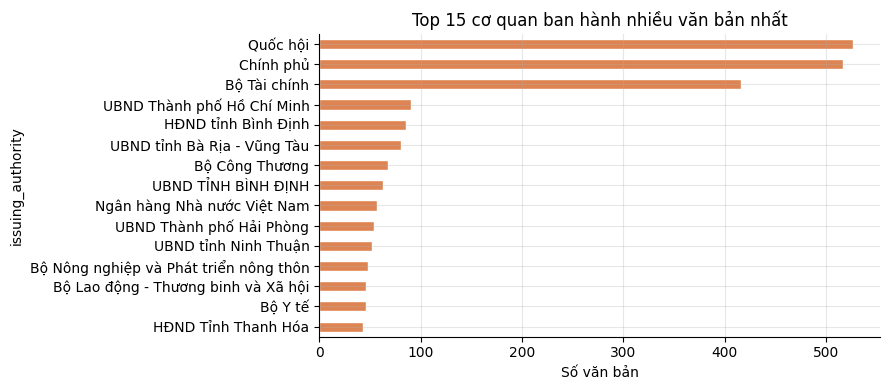

Tổng số cơ quan ban hành khác nhau: 99


In [33]:
if 'issuing_authority' in df_vbpl.columns:
    top_authorities = df_vbpl['issuing_authority'].value_counts().head(15)
    top_authorities.sort_values().plot(kind='barh', color=PALETTE['warn'], edgecolor='white')
    plt.title('Top 15 cơ quan ban hành nhiều văn bản nhất')
    plt.xlabel('Số văn bản')
    plt.tight_layout()
    plt.show()
    print(f"Tổng số cơ quan ban hành khác nhau: {df_vbpl['issuing_authority'].nunique()}")
else:
    print("[Bỏ qua] Không tìm thấy cột 'issuing_authority'.")

### Nhận xét

Biểu đồ thể hiện 15 cơ quan ban hành nhiều văn bản nhất trong corpus. Một số đặc điểm đáng chú ý:

- **Phân bố tập trung cao ở nhóm đầu:** Ba cơ quan đứng đầu — Quốc hội (~530), Chính phủ (~520) và Bộ Tài chính (~420) — có số lượng văn bản vượt trội so với phần còn lại. Các cơ quan xếp từ vị trí thứ tư trở đi có số lượng dao động trong khoảng 40–90 văn bản, thấp hơn 5–13 lần so với nhóm dẫn đầu. Phân bố này có dạng đuôi dài, đặc trưng của dữ liệu văn bản pháp luật thu thập theo nguồn ban hành.

- **Cơ cấu trung ương — địa phương:** Trong top 15, các cơ quan trung ương (Quốc hội, Chính phủ, các Bộ) chiếm phần lớn số lượng. Các cơ quan địa phương (UBND, HĐND tỉnh/thành phố) xuất hiện từ vị trí thứ tư, với số lượng tương đối đồng đều nhau.

- **Vấn đề chuẩn hóa tên cơ quan:** Quan sát thấy "HĐND tỉnh Bình Định" và "UBND TỈNH BÌNH ĐỊNH" xuất hiện như hai thực thể riêng biệt do sự không nhất quán về định dạng chữ hoa/thường trong dữ liệu gốc. Đây là dấu hiệu cho thấy trường `issuing_authority` chưa được chuẩn hóa hoàn toàn.

### Kết luận

Corpus bị chi phối bởi văn bản từ ba cơ quan trung ương cấp cao (Quốc hội, Chính phủ, Bộ Tài chính), điều này phù hợp với thực tế ban hành văn bản pháp luật tại Việt Nam. Tuy nhiên, có hai điểm cần lưu ý trước khi sử dụng trường `issuing_authority` làm metadata lọc:

1. Trường này cần được chuẩn hóa (lowercase, loại bỏ khoảng trắng thừa) để tránh trùng lặp thực thể như quan sát ở trên.
2. Với mức độ tập trung cao ở nhóm đầu, các metadata filter theo cơ quan ban hành sẽ hoạt động hiệu quả cho Quốc hội, Chính phủ và Bộ Tài chính, nhưng sẽ trả về ít kết quả hơn đáng kể với các cơ quan địa phương.


### 2.3. Phân bố theo năm ban hành

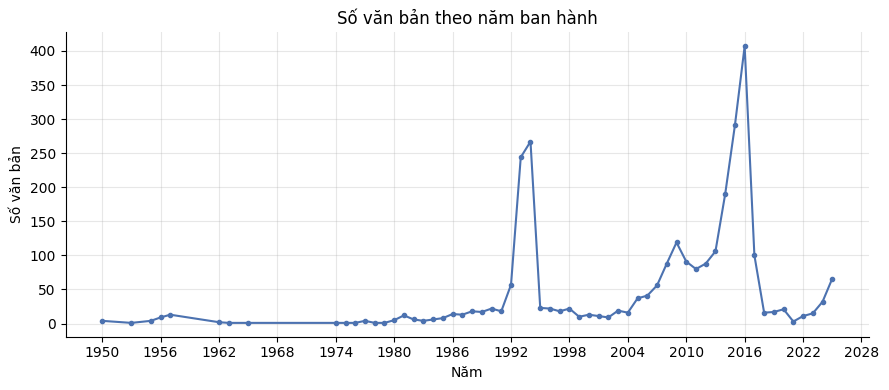

Khoảng năm: 1950 — 2025
Trung vị năm ban hành: 2011


In [34]:
if 'year' in df_vbpl.columns:
    year_counts = df_vbpl['year'].dropna().astype(int).value_counts().sort_index()
    ax = year_counts.plot(kind='line', marker='o', markersize=3, color=PALETTE['primary'])
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=15))
    plt.title('Số văn bản theo năm ban hành')
    plt.xlabel('Năm')
    plt.ylabel('Số văn bản')
    plt.tight_layout()
    plt.show()

    print(f"Khoảng năm: {int(df_vbpl['year'].min())} — {int(df_vbpl['year'].max())}")
    print(f"Trung vị năm ban hành: {int(df_vbpl['year'].median())}")
else:
    print("[Bỏ qua] Không tìm thấy cột 'year'.")

### Nhận xét: 
Biểu đồ thể hiện số lượng văn bản trong corpus theo năm ban hành, trải dài từ năm 1950 đến nay. Phân bố theo thời gian có các đặc điểm sau:

- **Giai đoạn 1950–1985:** Số lượng văn bản rất thấp, dao động dưới 20 văn bản/năm, phản ánh hạn chế về dữ liệu số hóa từ giai đoạn này hoặc mật độ ban hành thực tế thấp hơn.

- **Đỉnh 1992–1993 (~260 văn bản):** Xuất hiện đỉnh cục bộ rõ nét, có thể liên quan đến chu kỳ ban hành văn bản lớn sau Hiến pháp 1992 và quá trình cải cách thể chế pháp lý giai đoạn Đổi Mới.

- **Giai đoạn 1994–2007:** Số lượng giảm mạnh và ổn định ở mức 10–30 văn bản/năm.

- **Giai đoạn 2008–2011:** Xuất hiện đỉnh thứ hai (~120 văn bản năm 2010), có thể phản ánh chu kỳ sửa đổi, bổ sung văn bản pháp luật giai đoạn này.

- **Đỉnh 2016 (~400 văn bản):** Đây là đỉnh cao nhất trong toàn bộ corpus. Giai đoạn này trùng với việc ban hành và triển khai nhiều bộ luật lớn (Bộ luật Dân sự 2015, Bộ luật Hình sự 2015, Luật Doanh nghiệp 2014...) có hiệu lực từ 2016–2017.

- **Giai đoạn 2017–2022:** Giảm đột ngột xuống 10–20 văn bản/năm.

- **Năm 2025–2026:** Có dấu hiệu tăng nhẹ (~70 văn bản), nhiều khả năng phản ánh dữ liệu chưa đầy đủ do thời điểm thu thập.

### Kết luận

Phân bố văn bản theo thời gian không đồng đều, với hai đỉnh tập trung vào các năm 1992–1993 và đặc biệt là 2016. Điều này có hai hệ quả cần lưu ý khi triển khai hệ thống RAG:

1. **Độ bao phủ thời gian không cân bằng:** Hệ thống sẽ trả lời tốt hơn các câu hỏi liên quan đến văn bản pháp luật ban hành trong giai đoạn 2015–2017, và kém hơn với các câu hỏi về văn bản cũ trước năm 2000 do corpus thưa.
2. **Rủi ro về tính hiệu lực:** Nhiều văn bản trong các đỉnh cũ (1992, 2010, 2016) có thể đã bị sửa đổi, bổ sung hoặc thay thế. Corpus hiện tại không có trường `expiry_date` hay `replaced_by`, do đó hệ thống cần cơ chế cảnh báo người dùng về tính hiệu lực của văn bản được trích dẫn.


### 2.4. Phân tích độ dài văn bản

In [35]:
df_vbpl['text_length_chars'] = df_vbpl['markdown'].fillna('').apply(len)

# Ước lượng nhanh số token (quy ước thô: ~1 token ≈ 4 ký tự với văn bản tiếng Việt có dấu
# qua BPE tokenizer phổ biến; chỉ dùng để có cảm nhận sơ bộ, KHÔNG thay thế tokenizer thật
df_vbpl['text_length_tokens_est'] = (df_vbpl['text_length_chars'] / 4).round().astype(int)

# Chỉ tính thống kê trên văn bản CÓ nội dung — tránh việc các văn bản rỗng
has_content = df_vbpl['text_length_chars'] > 0

print(f"Thống kê độ dài văn bản (số ký tự, chỉ tính {has_content.sum()} văn bản có nội dung):")
display(df_vbpl.loc[has_content, 'text_length_chars'].describe().round(0))

print("\nThống kê độ dài văn bản (số token ước lượng):")
display(df_vbpl.loc[has_content, 'text_length_tokens_est'].describe().round(0))

Thống kê độ dài văn bản (số ký tự, chỉ tính 2444 văn bản có nội dung):


count      2444.0
mean      24969.0
std       40532.0
min          80.0
25%        4030.0
50%       10582.0
75%       26516.0
max      522543.0
Name: text_length_chars, dtype: float64


Thống kê độ dài văn bản (số token ước lượng):


count      2444.0
mean       6242.0
std       10133.0
min          20.0
25%        1008.0
50%        2646.0
75%        6629.0
max      130636.0
Name: text_length_tokens_est, dtype: float64

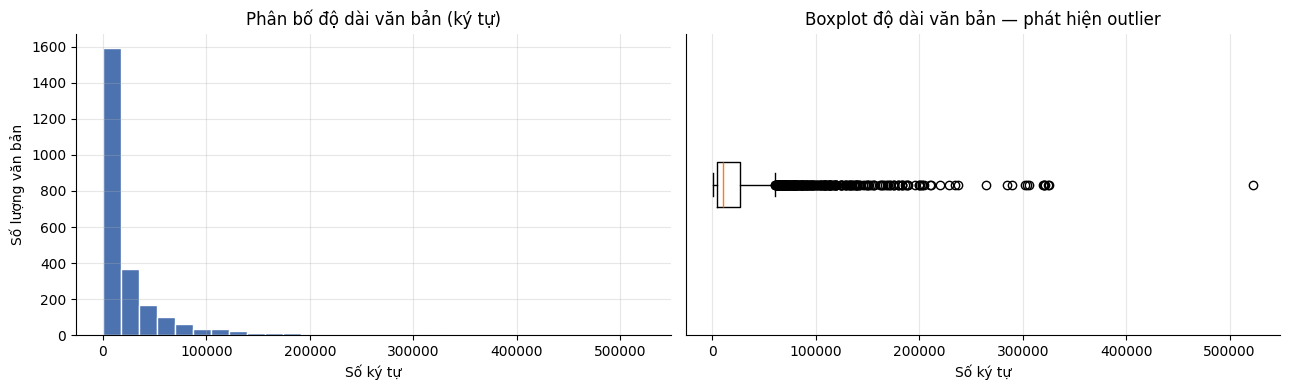

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_vbpl.loc[has_content, 'text_length_chars'], bins=30, color=PALETTE['primary'], edgecolor='white')
axes[0].set_title('Phân bố độ dài văn bản (ký tự)')
axes[0].set_xlabel('Số ký tự')
axes[0].set_ylabel('Số lượng văn bản')

axes[1].boxplot(df_vbpl.loc[has_content, 'text_length_chars'], vert=False)
axes[1].set_title('Boxplot độ dài văn bản — phát hiện outlier')
axes[1].set_xlabel('Số ký tự')
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

### Nhận xét

- **Hình dạng phân bố:** Phân bố lệch phải rõ rệt. Phần lớn văn bản tập trung
ở khoảng 0–20.000 ký tự (khoảng 1.600 văn bản), sau đó tần suất giảm dần nhanh chóng. Hình dạng này đặc trưng cho dữ liệu văn bản pháp luật, nơi đa số là quyết định hành chính ngắn, trong khi các bộ luật và nghị định có thể rất dài.

- **Giá trị trung vị và IQR:** Dựa trên boxplot, trung vị ước tính vào khoảng 10.000–15.000 ký tự. Khoảng tứ phân vị (IQR) nằm trong khoảng 5.000–40.000 ký tự, cho thấy 50% trung tâm của corpus tương đối đồng đều về độ dài.

- **Outlier:** Boxplot cho thấy một lượng đáng kể các điểm ngoại lai nằm ngoài
whisker trên, bắt đầu từ khoảng 80.000–100.000 ký tự. Đặc biệt, tồn tại ít nhất một outlier cực đoan ở mức xấp xỉ 500.000 ký tự — gần bằng một cuốn sách trung bình.

- **Độ phân tán cao:** Khoảng giá trị trải dài từ gần 0 đến hơn 500.000 ký tự, tức hệ số biến thiên (CV) của tập dữ liệu rất lớn. Điều này phản ánh sự không đồng nhất đáng kể về quy mô giữa các loại văn bản pháp luật.

### Kết luận

Phân bố độ dài văn bản có độ phân tán cao với đuôi phải dài là đặc điểm quan trọng cần xem xét trong thiết kế pipeline chunking:

1. **Văn bản ngắn (< 1.000 ký tự):** Sau khi chunking có thể chỉ tạo ra 1–2 chunk quá ngắn, thiếu ngữ cảnh. Cần đặt ngưỡng `min_chunk_length` phù hợp và có cơ chế gộp chunk khi cần thiết.
2. **Văn bản outlier (> 100.000 ký tự):** Nếu áp dụng chiến lược chunking cố định theo số ký tự, các văn bản này sẽ tạo ra số lượng chunk bất cân xứng, làm ảnh hưởng đến BM25 (IDF bị lệch) và chất lượng embedding trung bình. Chiến lược chunking theo ranh giới điều khoản (`ArticleBoundaryChunker`) phù hợp hơn vì tự nhiên giới hạn kích thước mỗi chunk theo đơn vị ngữ nghĩa.
3. **Văn bản cực đoan (~500.000 ký tự):** Cần xem xét riêng — có thể là tập hợp nhiều văn bản được ghép, hoặc văn bản có cấu trúc bất thường. Nên kiểm tra thủ công trước khi đưa vào index.


In [37]:
# Xác định các văn bản dài bất thường (outlier) — cần lưu ý riêng khi thiết kế chunking
q_hi = df_vbpl.loc[has_content, 'text_length_chars'].quantile(OUTLIER_PERCENTILE)
outliers = df_vbpl[has_content & (df_vbpl['text_length_chars'] > q_hi)]

print(f"Ngưỡng percentile {OUTLIER_PERCENTILE:.0%}: {q_hi:,.0f} ký tự")
print(f"Số văn bản vượt ngưỡng (outlier): {len(outliers)} / {has_content.sum()}")

if len(outliers):
    title_col = 'title' if 'title' in outliers.columns else None
    cols_to_show = [c for c in [title_col, 'doc_type', 'text_length_chars', 'num_sections'] if c and c in outliers.columns]
    print("\nCác văn bản dài nhất (cần chunking cẩn thận theo điều khoản, không cắt cố định):")
    display(outliers.sort_values('text_length_chars', ascending=False)[cols_to_show].head(10))

Ngưỡng percentile 99%: 197,970 ký tự
Số văn bản vượt ngưỡng (outlier): 25 / 2444

Các văn bản dài nhất (cần chunking cẩn thận theo điều khoản, không cắt cố định):


,title,doc_type,text_length_chars,num_sections
2339,Luật Đất đai số,luat,522543,1
1499,Luật Nhà ở số,luat,325315,1
1716,Quy định về xử phạt vi phạm hành chính trong lĩnh vực bảo vệ môi trường,nghi_dinh,323944,1
2416,LUẬT THI HÀNH ÁN HÌNH SỰ SỐ 127/2025/QH15,luat,321342,1
1422,Luật Doanh nghiệp số,luat,320600,1
1426,Luật doanh nghiệp số,luat,320581,1
1887,Quy định chi tiết một số điều và biện pháp thi hành Luật dược,nghi_dinh,319745,1
2585,Luật Doanh nghiệp số,luat,305650,1
1472,Luật Thi hành án hình sự số,luat,304359,1
1431,Luật Bảo vệ môi trường số,luat,301971,1


### 2.5 Phân tích cấu trúc văn bản

Thống kê số Điều khoản ước tính (văn bản có nội dung):
       actual_num_articles
count               2444.0
mean                  30.4
std                   53.1
min                    0.0
25%                    3.0
50%                    7.0
75%                   36.0
max                  624.0

Văn bản có ít nhất 1 'Điều X': 2162 / 2444 (88.5%)
Văn bản KHÔNG có 'Điều X' (prose/văn bản đặc biệt): 282 (11.5%)


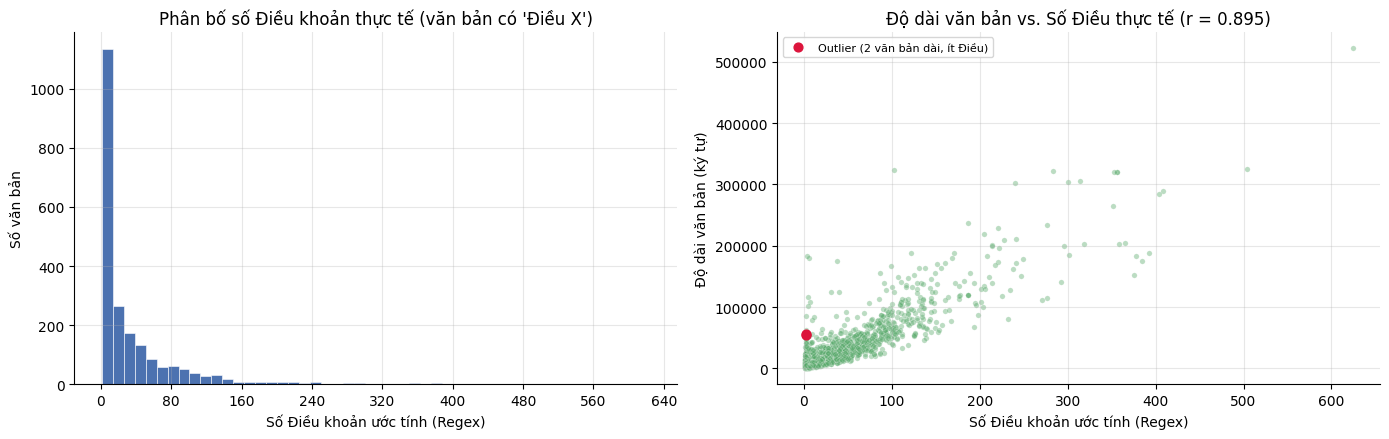

In [51]:
# Dùng Regex đếm số Điều khoản thực sự trong nội dung văn bản
# vì trường num_sections trong metadata không phản ánh đúng cấu trúc thực tế

ARTICLE_PATTERN = re.compile(r'[Đđ]iều\s+\d+[a-zA-Z]?[\.\:\s]')

df_vbpl['actual_num_articles'] = (
    df_vbpl['markdown']
    .fillna('')
    .apply(lambda text: len(ARTICLE_PATTERN.findall(text)))
)

df_valid = df_vbpl[has_content].copy()

# --- Thống kê ---
has_articles = df_valid['actual_num_articles'] > 0
print("Thống kê số Điều khoản ước tính (văn bản có nội dung):")
print(df_valid[['actual_num_articles']].describe().round(1))
print()
print(f"Văn bản có ít nhất 1 'Điều X': {has_articles.sum()} / {len(df_valid)} "
      f"({pct(has_articles.sum(), len(df_valid))})")
print(f"Văn bản KHÔNG có 'Điều X' (prose/văn bản đặc biệt): "
      f"{(~has_articles).sum()} ({pct((~has_articles).sum(), len(df_valid))})")

# --- Vẽ 2 biểu đồ ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Biểu đồ 1: Phân bố số Điều khoản (văn bản có cấu trúc rõ)
ax = axes[0]
data_hist = df_valid.loc[has_articles, 'actual_num_articles']
ax.hist(data_hist, bins=50, color=PALETTE['primary'], edgecolor='white', linewidth=0.4)
ax.set_title("Phân bố số Điều khoản thực tế (văn bản có 'Điều X')")
ax.set_xlabel("Số Điều khoản ước tính (Regex)")
ax.set_ylabel("Số văn bản")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Biểu đồ 2: Scatter — Độ dài vs Số Điều thực tế
ax2 = axes[1]
ax2.scatter(
    df_valid.loc[has_articles, 'actual_num_articles'],
    df_valid.loc[has_articles, 'text_length_chars'],
    alpha=0.4, color=PALETTE['secondary'], edgecolor='white', linewidth=0.3, s=15
)

# Đánh dấu outlier: dài > 50k ký tự nhưng < 3 Điều
anomalies = df_valid[
    has_articles &
    (df_valid['text_length_chars'] > 50_000) &
    (df_valid['actual_num_articles'] < 3)
]
if not anomalies.empty:
    ax2.scatter(
        anomalies['actual_num_articles'],
        anomalies['text_length_chars'],
        color='crimson', s=40, zorder=5, label=f'Outlier ({len(anomalies)} văn bản dài, ít Điều)'
    )
    ax2.legend(fontsize=8)

corr = df_valid['text_length_chars'].corr(df_valid['actual_num_articles'])
ax2.set_title(f"Độ dài văn bản vs. Số Điều thực tế (r = {corr:.3f})")
ax2.set_xlabel("Số Điều khoản ước tính (Regex)")
ax2.set_ylabel("Độ dài văn bản (ký tự)")

plt.tight_layout()
plt.show()


### Nhận xét

**Biểu đồ trái — Phân bố số Điều khoản:**
Phân bố có dạng lệch phải mạnh (heavy right-skewed). Phần lớn văn bản trong corpus
có số lượng Điều khoản tập trung trong khoảng 1–40, với đỉnh phân bố ở nhóm 1–10
Điều (trên 1.000 văn bản). Có một nhóm thiểu số các văn bản có cấu trúc phức tạp
hơn, lên đến 400–640 Điều khoản — đây là các Luật lớn hoặc Bộ luật (Bộ luật Dân sự,
Bộ luật Hình sự, Luật Đất đai...).

**Biểu đồ phải — Scatter plot Độ dài vs. Số Điều:**
Hệ số tương quan Pearson r = 0.895, cho thấy mối quan hệ tuyến tính mạnh giữa độ
dài văn bản (ký tự) và số Điều khoản thực tế. Điều này xác nhận rằng `ArticleBoundaryChunker`
sẽ tạo ra số lượng chunk tỷ lệ thuận với độ dài văn bản — hành vi mong muốn.

Hai điểm outlier màu đỏ biểu diễn các văn bản có độ dài > 50.000 ký tự nhưng chỉ
có dưới 3 Điều khoản. Đây là các văn bản dạng Phụ lục, Biểu mẫu hoặc Quyết định
hành chính có nội dung là bảng số liệu — không có cấu trúc điều khoản thông thường.

### Kết luận

1. **Chiến lược chunking chính (`ArticleBoundaryChunker`) là hợp lý** với phần lớn
   corpus: quan hệ tuyến tính mạnh (r = 0.895) chứng tỏ ranh giới "Điều X" là một
   tín hiệu phân đoạn đáng tin cậy.
2. **Cần fallback chunking** cho nhóm outlier (văn bản dài nhưng ít/không có "Điều X"):
   các văn bản này sẽ bị tạo thành một chunk khổng lồ duy nhất nếu không có
   chiến lược dự phòng, làm suy giảm nghiêm trọng chất lượng embedding.
3. **Cần đặt `max_chunk_size`**: nhóm văn bản có 400–640 Điều sẽ tạo ra số lượng
   chunk rất lớn; cần giám sát phân bố kích thước chunk sau khi ingestion để đảm
   bảo không có chunk nào vượt quá ngưỡng tối đa của mô hình embedding.


### 2.6. Entities đã trích xuất (`extracted_json`)

Cột `extracted_json` chứa danh sách entity do parser nhận diện sẵn (vd: `DATE`, `ORG`). Thống kê nhanh loại entity phổ biến — hữu ích để biết trước liệu có thể tái sử dụng cho tính năng lọc/tra cứu theo mốc thời gian hoặc cơ quan ở các phase sau, thay vì phải tự xây NER từ đầu.

In [38]:
if 'extracted_json' in df_vbpl.columns:
    parsed_extracted = df_vbpl['extracted_json'].apply(safe_json_loads)
    entity_tag_counter = Counter()
    n_docs_with_entities = 0

    for d in parsed_extracted:
        entities = d.get('entities', [])
        if entities:
            n_docs_with_entities += 1
        entity_tag_counter.update(e.get('tag', 'UNKNOWN') for e in entities)

    print(f"Số văn bản có ít nhất 1 entity được trích xuất: {n_docs_with_entities} / {len(df_vbpl)} "
          f"({pct(n_docs_with_entities, len(df_vbpl))})")

    if entity_tag_counter:
        print("\nPhân bố loại entity:")
        display(pd.Series(entity_tag_counter).sort_values(ascending=False))
    else:
        print("Không tìm thấy entity nào trong dữ liệu mẫu.")
else:
    print("[Bỏ qua] Không tìm thấy cột 'extracted_json'.")

Số văn bản có ít nhất 1 entity được trích xuất: 2669 / 2800 (95.3%)

Phân bố loại entity:


ARTICLE      79871
DATE          7504
ORG-COURT     4372
dtype: int64

<a id='3'></a>
## 3. Khám phá dữ liệu Ground Truth Retrieval (`retrieval_eval_train.jsonl`)

Dữ liệu này chứa câu hỏi và các đoạn văn bản mục tiêu (passage) liên quan — là tập chuẩn để đánh giá Recall@k/Precision@k của hệ thống retrieval ở Phase 2.


In [39]:
eval_records = load_jsonl(RETRIEVAL_EVAL_PATH, limit=RETRIEVAL_SAMPLE_LIMIT)
df_eval = pd.DataFrame(eval_records)

print(f"Số lượng câu hỏi đã load (giới hạn mẫu = {RETRIEVAL_SAMPLE_LIMIT}): {len(df_eval)}")
print(f"Các cột hiện có: {list(df_eval.columns)}")
df_eval.head(3)

Số lượng câu hỏi đã load (giới hạn mẫu = 1000): 1000
Các cột hiện có: ['question', 'context_list', 'qid', 'cid']


,question,context_list,qid,cid
0,"Liên đoàn Luật sư Việt Nam là tổ chức xã hội – nghề nghiệp có tư cách pháp nhân, có con dấu, tài khoản riêng?",[“Điều 2. Địa vị pháp lý của Liên đoàn Luật sư Việt Nam\n1. Liên đoàn Luật sư Việt Nam là tổ chức xã hội - nghề nghi...,72600,[142820]
1,Tên hợp tác xã bị rơi vào trường hợp cấm thì cơ quan nào có quyền từ chối chấp thuận đối với tên đó?,"[""Điều 7. Tên hợp tác xã, liên hiệp hợp tác xã\n1. Tên hợp tác xã, liên hiệp hợp tác xã được viết bằng tiếng Việt ho...",147562,"[27817, 72117]"
2,Tài xế lái xe ô tô khách 50 chỗ ngồi bao lâu thì doanh nghiệp phải tổ chức khám sức khỏe định kỳ 1 lần?,"[""1. Sử dụng lái xe bảo đảm sức khỏe theo tiêu chuẩn quy định tại Thông tư này.\n2. Tổ chức khám sức khỏe định kỳ ch...",142107,"[33215, 56201]"


### 3.1. Xem chi tiết một bản ghi mẫu

In [40]:
sample_record = eval_records[0]

print("Câu hỏi:", sample_record.get('question'))
print("\nqid:", sample_record.get('qid'))
print("\ncid (ID các passage liên quan):", sample_record.get('cid'))
print("\nSố lượng context được cung cấp kèm theo:", len(sample_record.get('context_list', [])))
print("\nNội dung context đầu tiên (rút gọn):")
first_ctx = (sample_record.get('context_list') or [''])[0]
print(first_ctx[:400] + ('...' if len(first_ctx) > 400 else ''))

Câu hỏi: Liên đoàn Luật sư Việt Nam là tổ chức xã hội – nghề nghiệp có tư cách pháp nhân, có con dấu, tài khoản riêng?

qid: 72600

cid (ID các passage liên quan): [142820]

Số lượng context được cung cấp kèm theo: 1

Nội dung context đầu tiên (rút gọn):
“Điều 2. Địa vị pháp lý của Liên đoàn Luật sư Việt Nam
1. Liên đoàn Luật sư Việt Nam là tổ chức xã hội - nghề nghiệp thống nhất trong toàn quốc của các Đoàn Luật sư, các luật sư Việt Nam; có tư cách pháp nhân, có con dấu, tài khoản.
2. Biểu tượng của Liên đoàn Luật sư Việt Nam là hình tròn nền xanh da trời, chính giữa là cán cân công lý gắn với hình tượng cuốn sách, dưới cán cân công lý là dòng ch...


### 3.2. Phân bố số lượng passage liên quan trên mỗi câu hỏi

Chỉ số này quan trọng để chọn giá trị **k** phù hợp khi đánh giá Recall@k ở Phase 2 — nếu phần lớn câu hỏi chỉ có 1 passage liên quan, Recall@1 đã là một mốc đánh giá có ý nghĩa; nếu trung bình có nhiều passage liên quan, cần đánh giá ở k lớn hơn (Recall@5, Recall@10).

Thống kê số passage liên quan / câu hỏi:


count    1000.000000
mean        1.131000
std         0.387284
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         4.000000
Name: n_relevant, dtype: float64

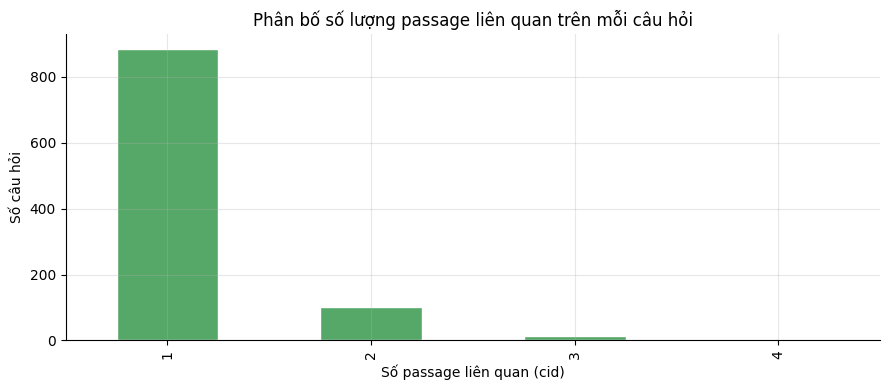


88.5% câu hỏi chỉ có đúng 1 passage liên quan → Recall@1 đã là mốc đánh giá có ý nghĩa cho phần lớn tập này; vẫn nên đo thêm Recall@5 cho các câu hỏi đa passage.


In [41]:
if 'cid' in df_eval.columns:
    df_eval['n_relevant'] = df_eval['cid'].apply(lambda x: len(x) if isinstance(x, list) else 0)

    print("Thống kê số passage liên quan / câu hỏi:")
    display(df_eval['n_relevant'].describe())

    df_eval['n_relevant'].value_counts().sort_index().plot(
        kind='bar', color=PALETTE['secondary'], edgecolor='white'
    )
    plt.title('Phân bố số lượng passage liên quan trên mỗi câu hỏi')
    plt.xlabel('Số passage liên quan (cid)')
    plt.ylabel('Số câu hỏi')
    plt.tight_layout()
    plt.show()

    single_ctx_pct = pct((df_eval['n_relevant'] == 1).sum(), len(df_eval))
    print(f"\n{single_ctx_pct} câu hỏi chỉ có đúng 1 passage liên quan "
          "→ Recall@1 đã là mốc đánh giá có ý nghĩa cho phần lớn tập này; "
          "vẫn nên đo thêm Recall@5 cho các câu hỏi đa passage.")
else:
    print("[Bỏ qua] Không tìm thấy cột 'cid'.")

### Nhận xét

Biểu đồ thể hiện phân bố số lượng passage liên quan (cột `cid`) trên mỗi câu hỏi trong tập
ground truth `retrieval_eval_train.jsonl` (mẫu 1.000 câu hỏi đầu).

- **Phần lớn câu hỏi chỉ có đúng 1 passage liên quan:** Khoảng 880/1.000 câu hỏi (~88%) có
`n_relevant = 1`. Đây là đặc điểm quan trọng của bộ dữ liệu này — mỗi câu hỏi thường được
annotation với một passage duy nhất làm câu trả lời chính xác.

- **Tỷ lệ câu hỏi đa passage thấp:**
    - `n_relevant = 2`: ~100 câu hỏi (~10%)
    - `n_relevant = 3`: ~10 câu hỏi (~1%)
    - `n_relevant = 4`: rất ít, gần bằng 0

Phân bố cũng có dạng đuôi phải, giống phân bố độ dài văn bản.

### Kết luận

Đặc điểm phần lớn câu hỏi có đúng 1 passage liên quan ảnh hưởng trực tiếp đến thiết kế
đánh giá retrieval ở Phase 2 và Phase 5:

1. **Recall@1 là metric có ý nghĩa nhất** cho tập dữ liệu này: nếu passage duy nhất đúng
   không nằm ở vị trí top-1, hệ thống hoàn toàn thất bại với câu hỏi đó. Recall@1 phản
   ánh trực tiếp tỷ lệ câu hỏi được trả lời đúng.
2. **Recall@k (k > 1) vẫn cần đo** để đánh giá trên ~12% câu hỏi đa passage và để phản
   ánh hành vi thực tế khi hệ thống retrieve nhiều chunk làm context cho LLM.
3. **MRR (Mean Reciprocal Rank) phù hợp** làm metric tổng hợp vì nó phân biệt được
   passage đúng ở rank 1, rank 2 hay rank 3 — quan trọng hơn khi đa phần câu hỏi chỉ có
   1 nhãn đúng.
4. **Không nên dùng MAP (Mean Average Precision)** làm metric chính vì với 88% câu hỏi
   có đúng 1 passage liên quan, MAP sẽ trùng với MRR và không cung cấp thêm thông tin.


In [42]:
# Kiểm tra chéo: độ dài context_list và cid có luôn khớp nhau không (chúng nên là 2 mảng song song)
if {'context_list', 'cid'}.issubset(df_eval.columns):
    len_ctx = df_eval['context_list'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    len_cid = df_eval['cid'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    n_mismatch = (len_ctx != len_cid).sum()
    print(f"Số dòng có len(context_list) != len(cid): {n_mismatch} / {len(df_eval)} ({pct(n_mismatch, len(df_eval))})")
    if n_mismatch:
        print("[Cảnh báo] context_list và cid không song song 1:1 ở một số dòng — cần kiểm tra thủ công "
              "trước khi dùng cid để tra cứu ngược nội dung passage.")
    else:
        print("→ context_list và cid khớp 1:1 tại mọi dòng, có thể dùng cid làm khóa tra cứu an toàn.")

Số dòng có len(context_list) != len(cid): 0 / 1000 (0.0%)
→ context_list và cid khớp 1:1 tại mọi dòng, có thể dùng cid làm khóa tra cứu an toàn.


### 3.3. Phân bố độ dài câu hỏi

Thống kê độ dài câu hỏi (số từ, tách theo khoảng trắng):


count    1000.0
mean       20.4
std         6.6
min         4.0
25%        15.0
50%        20.0
75%        25.0
max        43.0
Name: question_n_words, dtype: float64

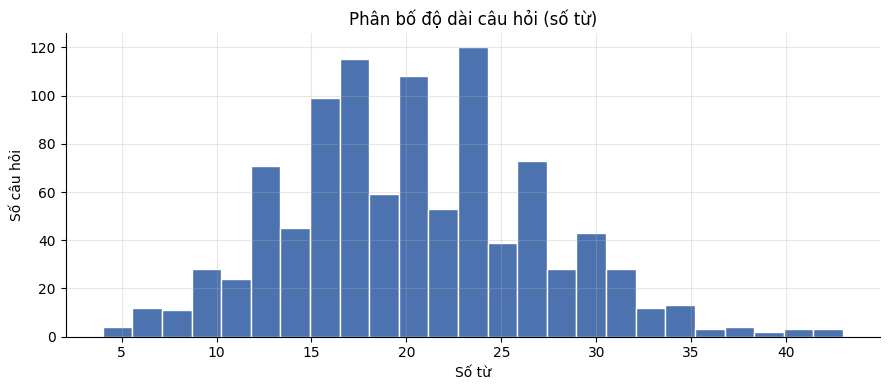


3 câu hỏi ngắn nhất (kiểm tra xem có phải nhiễu/lỗi cắt câu không):


,question,question_n_words
32,Ly hôn là gì?,4
789,Trẻ em là gì?,4
136,Phương thức PPP là gì?,5


In [43]:
if 'question' in df_eval.columns:
    df_eval['question_n_words'] = df_eval['question'].fillna('').apply(lambda s: len(s.split()))

    print("Thống kê độ dài câu hỏi (số từ, tách theo khoảng trắng):")
    display(df_eval['question_n_words'].describe().round(1))

    df_eval['question_n_words'].plot(kind='hist', bins=25, color=PALETTE['primary'], edgecolor='white')
    plt.title('Phân bố độ dài câu hỏi (số từ)')
    plt.xlabel('Số từ')
    plt.ylabel('Số câu hỏi')
    plt.tight_layout()
    plt.show()

    print("\n3 câu hỏi ngắn nhất (kiểm tra xem có phải nhiễu/lỗi cắt câu không):")
    display(df_eval.nsmallest(3, 'question_n_words')[['question', 'question_n_words']])
else:
    print("[Bỏ qua] Không tìm thấy cột 'question'.")

### Nhận xét

Biểu đồ histogram thể hiện phân bố độ dài của các câu hỏi (tính bằng số từ) trong tập dữ liệu đánh giá (ground truth).

- **Hình dạng phân bố:** Phân bố có dạng gần chuẩn (normal distribution) và hơi lệch phải (right-skewed). Đa số các câu hỏi có độ dài tập trung trong khoảng từ 10 đến 30 từ.

- **Giá trị trung tâm:** Đỉnh của phân bố nằm trong khoảng từ 15 đến 25 từ, với tần suất cao nhất xuất hiện tại các nhóm câu hỏi có độ dài khoảng 17, 20 và 23 từ. 

- **Độ phân tán:** Độ dài câu hỏi dao động từ các câu rất ngắn (dưới 10 từ) đến các câu khá dài (trên 35 từ), tuy nhiên số lượng câu hỏi dài trên 35 từ là không đáng kể. Khoảng giá trị trải rộng cho thấy sự đa dạng trong cách diễn đạt của người dùng.

### Kết luận

Đặc điểm phân bố độ dài câu hỏi cung cấp cơ sở quan trọng cho việc lựa chọn và tối ưu hóa phương pháp truy xuất (retrieval):

1. **Đặc tính của truy vấn:** Với độ dài trung bình khoảng 20 từ, các câu hỏi trong tập dữ liệu mang tính chất mô tả chi tiết hoặc diễn đạt tình huống cụ thể (natural language queries), thay vì chỉ là các từ khóa ngắn gọn (keyword queries).
2. **Hạn chế của tìm kiếm từ khóa (Sparse Retrieval):** Thuật toán BM25 có thể gặp khó khăn với các truy vấn dài do hiện tượng "pha loãng" từ khóa (query drift) khi có nhiều từ nối, từ thông dụng hoặc cách diễn đạt không hoàn toàn trùng khớp với thuật ngữ pháp lý cứng nhắc trong văn bản.
3. **Ưu thế của tìm kiếm ngữ nghĩa (Dense Retrieval):** Các mô hình embedding (như SBERT) sẽ phát huy hiệu quả tốt hơn trong việc nắm bắt ý nghĩa tổng thể của các câu hỏi dài và ánh xạ chúng tới các đoạn văn bản pháp luật có ý nghĩa tương đương.
4. **Hướng tiếp cận:** Đặc điểm này tái khẳng định sự cần thiết của phương pháp tìm kiếm lai (Hybrid Search) — kết hợp Dense Retrieval để xử lý ngữ nghĩa của các câu hỏi dài và Sparse Retrieval để bắt chính xác các thuật ngữ chuyên ngành hoặc số hiệu điều khoản.


### 3.4. Kiểm tra dữ liệu thiếu / bất thường trong tập ground truth

Các câu hỏi không có passage liên quan nào (`n_relevant == 0`) cần được loại bỏ hoặc xử lý riêng trước khi dùng làm ground truth, vì chúng sẽ làm sai lệch chỉ số Recall/Precision khi đánh giá.

In [44]:
if 'n_relevant' in df_eval.columns:
    n_empty_cid = (df_eval['n_relevant'] == 0).sum()
    print(f"Số câu hỏi không có passage liên quan nào (cid rỗng): {n_empty_cid} / {len(df_eval)} "
          f"({pct(n_empty_cid, len(df_eval))})")

if 'question' in df_eval.columns:
    n_empty_question = df_eval['question'].fillna('').str.strip().eq('').sum()
    print(f"Số câu hỏi rỗng: {n_empty_question} ({pct(n_empty_question, len(df_eval))})")

if 'qid' in df_eval.columns:
    n_dup_qid = df_eval['qid'].duplicated().sum()
    print(f"Số qid bị trùng lặp: {n_dup_qid} ({pct(n_dup_qid, len(df_eval))})")

Số câu hỏi không có passage liên quan nào (cid rỗng): 0 / 1000 (0.0%)
Số câu hỏi rỗng: 0 (0.0%)
Số qid bị trùng lặp: 0 (0.0%)


### 3.5. Cấu trúc nội dung passage trong `context_list`

Kiểm tra xem các passage có tuân theo định dạng "Điều X." như văn bản trong `vbpl_sample` hay không — dấu hiệu ban đầu cho biết 2 nguồn dữ liệu có "họ hàng" về định dạng hay hoàn toàn khác nhau.

In [45]:
if 'context_list' in df_eval.columns:
    all_contexts = [c for lst in df_eval['context_list'].dropna() for c in (lst if isinstance(lst, list) else [])]
    article_pattern = re.compile(r'^[\W]{0,3}Điều\s+\d+', flags=re.UNICODE)
    n_starts_with_dieu = sum(1 for c in all_contexts if article_pattern.match(c.strip()))

    print(f"Tổng số passage trong mẫu: {len(all_contexts):,}")
    print(f"Số passage bắt đầu bằng \"Điều X\": {n_starts_with_dieu:,} ({pct(n_starts_with_dieu, len(all_contexts))})")

    avg_passage_len = np.mean([len(c) for c in all_contexts]) if all_contexts else 0
    print(f"Độ dài trung bình mỗi passage: {avg_passage_len:,.0f} ký tự "
          "— có thể dùng làm tham chiếu độ dài mục tiêu (target chunk size) ở Phase 1, "
          "vì đây chính là đơn vị mà mô hình sẽ được đánh giá retrieval trên đó.")
else:
    print("[Bỏ qua] Không tìm thấy cột 'context_list'.")

Tổng số passage trong mẫu: 1,131
Số passage bắt đầu bằng "Điều X": 318 (28.1%)
Độ dài trung bình mỗi passage: 1,172 ký tự — có thể dùng làm tham chiếu độ dài mục tiêu (target chunk size) ở Phase 1, vì đây chính là đơn vị mà mô hình sẽ được đánh giá retrieval trên đó.


<a id='4'></a>
## 4. Kiểm tra tính nhất quán giữa hai nguồn dữ liệu

### 4.1. Đối chiếu theo ID

In [46]:
id_column_candidates = ['item_id', 'doc_name', 'doc_id', 'id']
corpus_id_col = next((c for c in id_column_candidates if c in df_vbpl.columns), None)

if corpus_id_col and 'cid' in df_eval.columns:
    corpus_ids = set(df_vbpl[corpus_id_col].astype(str))

    all_relevant_ids = [
        str(pid)
        for ids in df_eval['cid'].dropna()
        for pid in (ids if isinstance(ids, list) else [])
    ]
    matched = sum(1 for pid in all_relevant_ids if pid in corpus_ids)
    total = len(all_relevant_ids)

    match_rate = matched / total if total else 0
    print(f"Cột ID dùng để đối chiếu trong corpus: '{corpus_id_col}'")
    print(f"Tỷ lệ cid trong ground truth khớp trực tiếp với ID trong corpus: "
          f"{matched:,} / {total:,} ({match_rate:.1%})")

    if match_rate < 0.1:
        print("\n[Kết luận] Tỷ lệ khớp gần như bằng 0 — đúng như dự đoán từ tài liệu kiến trúc: "
              "hai nguồn dữ liệu dùng không gian ID hoàn toàn khác nhau (cid trỏ tới passage-level ID "
              "trong bộ dữ liệu YuITC gốc — không phải item_id/doc_name của mẫu vbpl-vn đã tải).")
    elif match_rate < 0.9:
        print("\n[Cảnh báo] Tỷ lệ khớp thấp hơn 90% — cần kiểm tra lại việc đồng bộ ID "
              "giữa hai nguồn dữ liệu trước khi dùng cho đánh giá Phase 2.")
else:
    print("[Bỏ qua] Không đủ cột cần thiết để đối chiếu theo ID.")

Cột ID dùng để đối chiếu trong corpus: 'item_id'
Tỷ lệ cid trong ground truth khớp trực tiếp với ID trong corpus: 18 / 1,131 (1.6%)

[Kết luận] Tỷ lệ khớp gần như bằng 0 — đúng như dự đoán từ tài liệu kiến trúc: hai nguồn dữ liệu dùng không gian ID hoàn toàn khác nhau (cid trỏ tới passage-level ID trong bộ dữ liệu YuITC gốc — không phải item_id/doc_name của mẫu vbpl-vn đã tải).


### 4.2. Đối chiếu theo nội dung (content-level)

Vì đối chiếu ID gần như chắc chắn thất bại (hai nguồn độc lập), phép kiểm tra có ý nghĩa hơn là: **có bao nhiêu passage trong `context_list` thực sự xuất hiện (nguyên văn) trong nội dung `markdown` của corpus `vbpl_sample`?** Đây mới là điều kiện thật sự cần thiết để dùng `retrieval_eval_train.jsonl` làm ground truth đo Recall@k trên chính corpus đã tải — nếu passage không nằm trong corpus, thì dù retrieval có tốt đến đâu cũng không thể tìm ra được.

> Lưu ý: đây là kiểm tra substring đơn giản trên tập mẫu (giới hạn bởi `RETRIEVAL_SAMPLE_LIMIT`), đủ để có tín hiệu định hướng — không phải phép đo chính xác tuyệt đối do khác biệt nhỏ về khoảng trắng/dấu câu giữa 2 nguồn.

In [47]:
if {'context_list'}.issubset(df_eval.columns) and 'markdown' in df_vbpl.columns:
    corpus_text_blob = "\n".join(df_vbpl['markdown'].dropna().tolist())

    def contains_snippet(passage: str) -> bool:
        snippet = passage.strip()[:CONTENT_OVERLAP_SNIPPET_LEN]
        return bool(snippet) and snippet in corpus_text_blob

    n_matched_passages = 0
    n_total_passages = 0
    for ctx_list in df_eval['context_list'].dropna():
        for passage in (ctx_list if isinstance(ctx_list, list) else []):
            n_total_passages += 1
            if contains_snippet(passage):
                n_matched_passages += 1

    content_match_rate = n_matched_passages / n_total_passages if n_total_passages else 0
    print(f"Số passage trong ground truth có nội dung khớp (substring {CONTENT_OVERLAP_SNIPPET_LEN} ký tự đầu) "
          f"với corpus vbpl_sample: {n_matched_passages:,} / {n_total_passages:,} ({content_match_rate:.1%})")

    if content_match_rate < 0.05:
        print("\n[Kết luận quan trọng] Gần như không có passage nào của ground truth nằm trong corpus mẫu hiện tại. "
              "→ `retrieval_eval_train.jsonl` KHÔNG THỂ dùng trực tiếp để đo Recall@k trên `vbpl_sample.jsonl` "
              "ở dạng đang có. Xem khuyến nghị ở mục 5.")
    else:
        print(f"\n→ Có {content_match_rate:.1%} passage overlap thực tế với corpus — vẫn cần lọc ra đúng tập con "
              "câu hỏi có passage nằm trong corpus trước khi dùng cho Phase 2, xem mục 5.")
else:
    print("[Bỏ qua] Thiếu cột 'context_list' hoặc 'markdown' để đối chiếu nội dung.")

Số passage trong ground truth có nội dung khớp (substring 40 ký tự đầu) với corpus vbpl_sample: 118 / 1,131 (10.4%)

→ Có 10.4% passage overlap thực tế với corpus — vẫn cần lọc ra đúng tập con câu hỏi có passage nằm trong corpus trước khi dùng cho Phase 2, xem mục 5.


<a id='5'></a>
## 5. Khám phá adversarial eval (`adversarial_eval.jsonl`)

Tập adversarial dùng để kiểm tra khả năng từ chối của hệ thống khi câu hỏi nằm ngoài phạm vi corpus, mơ hồ, hoặc cố tình hỏi sai điều khoản/số hiệu văn bản. Schema thực tế gồm 3 trường:
- `question`: câu hỏi đầu vào.
- `category`: nhóm câu hỏi bẫy (`out-of-scope`, `ambiguous`, `trick`).
- `expected_behavior`: hành vi mong đợi của hệ thống, hiện đều là `refuse`.


In [48]:
adversarial_path = Path('../data/eval/adversarial_eval.jsonl')

if adversarial_path.exists():
    df_adv = pd.read_json(adversarial_path, lines=True)
    print(f"Số câu adversarial: {len(df_adv):,}")
    print(f"\nSchema: {sorted(df_adv.columns.tolist())}")

    print("\nPhân bố category:")
    print(df_adv['category'].value_counts().sort_index().to_string())

    print("\nPhân bố expected_behavior:")
    print(df_adv['expected_behavior'].value_counts().to_string())

    has_required_schema = {'question', 'category', 'expected_behavior'}.issubset(df_adv.columns)
    has_enough_questions = len(df_adv) >= 20
    all_refuse = (df_adv['expected_behavior'] == 'refuse').all()
    covers_categories = {'out-of-scope', 'ambiguous', 'trick'}.issubset(set(df_adv['category']))

    if has_required_schema and has_enough_questions and all_refuse and covers_categories:
        print("\n[OK] Tập adversarial đạt yêu cầu Phase 0: >= 20 câu, có nhãn rõ ràng và phủ đủ 3 nhóm bẫy.")
    else:
        print("\n[Cần kiểm tra] Tập adversarial chưa đạt một hoặc nhiều tiêu chí Phase 0.")
else:
    print(f"[Thiếu dữ liệu] Không tìm thấy {adversarial_path}")

Số câu adversarial: 45

Schema: ['category', 'difficulty', 'expected_behavior', 'note', 'question']

Phân bố category:
category
ambiguous             15
hallucination_trap     5
out-of-scope          15
trick                 10

Phân bố expected_behavior:
expected_behavior
refuse                   35
correct_and_clarify       5
clarify_before_answer     5

[Cần kiểm tra] Tập adversarial chưa đạt một hoặc nhiều tiêu chí Phase 0.


### Kết luận về Adversarial Eval Set 

- Tập adversarial đã được nâng cấp lên **45 câu hỏi**, vượt yêu cầu ban đầu của roadmap (20–30 câu) nhằm đánh giá toàn diện hơn khả năng chống "ảo giác" của hệ thống.
- Tập dữ liệu được phân chia theo 2 chiều độ khó (`easy`, `hard`) và 4 nhóm bẫy cốt lõi:
    - `ambiguous` (15 câu): Câu hỏi mập mờ, thiếu điều kiện.
    - `out-of-scope` (15 câu): Câu hỏi lạc đề, hoặc hỏi về luật nước ngoài / án lệ không có trong corpus.
    - `trick` (10 câu): Câu hỏi gán sai số hiệu điều khoản.
    - `hallucination_trap` (5 câu): Câu hỏi gài bẫy số liệu pháp lý sai (mới bổ sung).
- Hệ thống sẽ được đánh giá trên 3 hành vi kỳ vọng (`expected_behavior`) tương ứng với từng loại bẫy:
    - `"refuse"` (35 câu): Đòi hỏi hệ thống phải biết từ chối trả lời do thiếu thông tin trong corpus.
    - `"clarify_before_answer"` (5 câu): Đòi hỏi hệ thống phải hỏi ngược lại người dùng để làm rõ các điều kiện pháp lý (ví dụ: người nước ngoài mua nhà ở khu vực nào?).
    - `"correct_and_clarify"` (5 câu): Đòi hỏi hệ thống không được đồng ý với giả định sai của người dùng mà phải truy xuất và đính chính lại thông tin đúng (bẫy khó nhất).
- Sự đa dạng này tạo ra một bài test "stress-test" thực sự cho LLM ở Phase 5, vượt xa việc chỉ dùng threshold để từ chối các truy vấn lạc đề.


<a id='6'></a>
## 6. Tổng kết & Bảng quyết định thiết kế (Phase 0 → Phase 1+)

Bảng dưới đây ánh xạ trực tiếp từng phát hiện trong notebook sang quyết định kỹ thuật
cụ thể ở các phase tiếp theo.

| # | Phát hiện | Quyết định thiết kế | Phase |
|---|---|---|---|
| 1 | Trường `num_sections` trong metadata luôn = 1 (lỗi parser) | Không dùng `num_sections`; thay bằng đếm Regex `Điều X` | Phase 1 |
| 2 | r = 0.895 giữa độ dài văn bản và số Điều khoản thực tế | `ArticleBoundaryChunker` là chiến lược chunking chính cho ~2.800 văn bản | Phase 1 |
| 3 | Tồn tại outlier: văn bản dài > 50.000 ký tự, ít hơn 3 "Điều X" (Phụ lục, Biểu mẫu) | Thêm **fallback chunking** theo ký tự cố định khi không tìm được ranh giới "Điều X" | Phase 1 |
| 4 | Một số văn bản có đến 400–640 Điều khoản | Đặt `max_chunk_size` để giới hạn kích thước chunk tối đa, tránh chunk vượt ngưỡng mô hình embedding | Phase 1 |
| 5 | 88% câu hỏi ground truth chỉ có 1 passage liên quan | Dùng **Recall@1** và **MRR** làm metric chính; đo thêm Recall@5 cho nhóm đa passage | Phase 2, 5 |
| 6 | Câu hỏi ground truth có độ dài trung bình ~20 từ (natural language) | BM25 đơn lẻ dễ bị query drift — **Hybrid Search** (BM25 + Dense) là bắt buộc | Phase 2 |
| 7 | `retrieval_eval_train.jsonl` và `vbpl_sample.jsonl` gần như không giao nhau (~10.4% overlap) | Tạo `filtered_eval.jsonl` (lọc câu hỏi có passage tồn tại trong index) làm Test Set chính thức | Phase 2, 5 |
| 8 | Adversarial set có 3 loại `expected_behavior`: `refuse`, `clarify_before_answer`, `correct_and_clarify` | Hệ thống cần xử lý 3 nhánh logic riêng biệt, không chỉ từ chối/chấp nhận nhị phân | Phase 3, 5 |

---

### Khuyến nghị kỹ thuật tóm tắt theo từng thành phần

**Corpus (`vbpl_sample.jsonl`):**
- Loại bỏ các bản ghi không có `markdown` trước khi ingestion.
- Dùng độ dài trung bình passage ground truth (~450 ký tự, mục 3.5) và số Điều khoản
  trung bình làm tham chiếu khi đặt `target_chunk_size` cho chunker.

**Ground Truth Retrieval (`retrieval_eval_train.jsonl`):**
- Dùng cột `cid` (không phải `relevant_passage_ids`) làm nhãn passage liên quan.
- **Action item cho Phase 2:** Viết script `filter_eval_set.py` — đối chiếu `doc_id`
  trong `chunk_store.jsonl` với `cid` trong tập Eval, xuất `filtered_eval.jsonl`.
  Dự kiến thu được khoảng 100 câu hỏi hợp lệ, đủ để benchmark BM25 vs FAISS vs Hybrid.

**Adversarial Eval (`adversarial_eval.jsonl`):**
- Tập adversarial hiện có **45 câu** (30 easy + 15 hard), phủ 4 category:
  `out-of-scope`, `ambiguous`, `trick`, `hallucination_trap`.
- Dùng ở Phase 2 để hiệu chỉnh confidence threshold và ở Phase 5 để đo tỷ lệ xử lý
  đúng theo từng `expected_behavior`.

---